# Salary Prediction Model for Company X
## Data Science Internship Project

**Author:** Pankaj Singh

**Objective:** Build a model to predict expected CTC for job applicants to eliminate salary discrimination

### Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


### Load Data

In [2]:
# Load the dataset
df = pd.read_csv('expected_ctc.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display first few rows
df.head()

Dataset shape: (25000, 29)
Number of rows: 25000
Number of columns: 29


,IDX,Applicant_ID,Total_Experience,Total_Experience_in_field_applied,Department,Role,Industry,Organization,Designation,Education,...,Curent_Location,Preferred_location,Current_CTC,Inhand_Offer,Last_Appraisal_Rating,No_Of_Companies_worked,Number_of_Publications,Certifications,International_degree_any,Expected_CTC
0,1,22753,0,0,NaN,NaN,NaN,NaN,NaN,PG,...,Guwahati,Pune,0,N,NaN,0,0,0,0,384551
1,2,51087,23,14,HR,Consultant,Analytics,H,HR,Doctorate,...,Bangalore,Nagpur,2702664,Y,Key_Performer,2,4,0,0,3783729
2,3,38413,21,12,Top Management,Consultant,Training,J,NaN,Doctorate,...,Ahmedabad,Jaipur,2236661,Y,Key_Performer,5,3,0,0,3131325
3,4,11501,15,8,Banking,Financial Analyst,Aviation,F,HR,Doctorate,...,Kanpur,Kolkata,2100510,N,C,5,3,0,0,2608833
4,5,58941,10,5,Sales,Project Manager,Insurance,E,Medical Officer,Grad,...,Ahmedabad,Ahmedabad,1931644,N,C,2,3,0,0,2221390


### Basic Data Info

In [3]:
# Dataset information
print("=== DATASET INFO ===")
df.info()

print("\n=== BASIC STATISTICS ===")
df.describe()

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   IDX                                25000 non-null  int64  
 1   Applicant_ID                       25000 non-null  int64  
 2   Total_Experience                   25000 non-null  int64  
 3   Total_Experience_in_field_applied  25000 non-null  int64  
 4   Department                         22222 non-null  object 
 5   Role                               24037 non-null  object 
 6   Industry                           24092 non-null  object 
 7   Organization                       24092 non-null  object 
 8   Designation                        21871 non-null  object 
 9   Education                          25000 non-null  object 
 10  Graduation_Specialization          18820 non-null  object 
 11  University_Grad                  

### Missing Values Analysis

=== MISSING VALUES ANALYSIS ===
                        Column  Missing_Count  Missing_Percentage
16          PHD_Specialization          11881              47.524
17              University_PHD          11881              47.524
18         Passing_Year_Of_PHD          11881              47.524
13           PG_Specialization           7692              30.768
15          Passing_Year_Of_PG           7692              30.768
14               University_PG           7692              30.768
10   Graduation_Specialization           6180              24.720
12  Passing_Year_Of_Graduation           6180              24.720
11             University_Grad           6180              24.720
8                  Designation           3129              12.516
4                   Department           2778              11.112
5                         Role            963               3.852
6                     Industry            908               3.632
23       Last_Appraisal_Rating            90

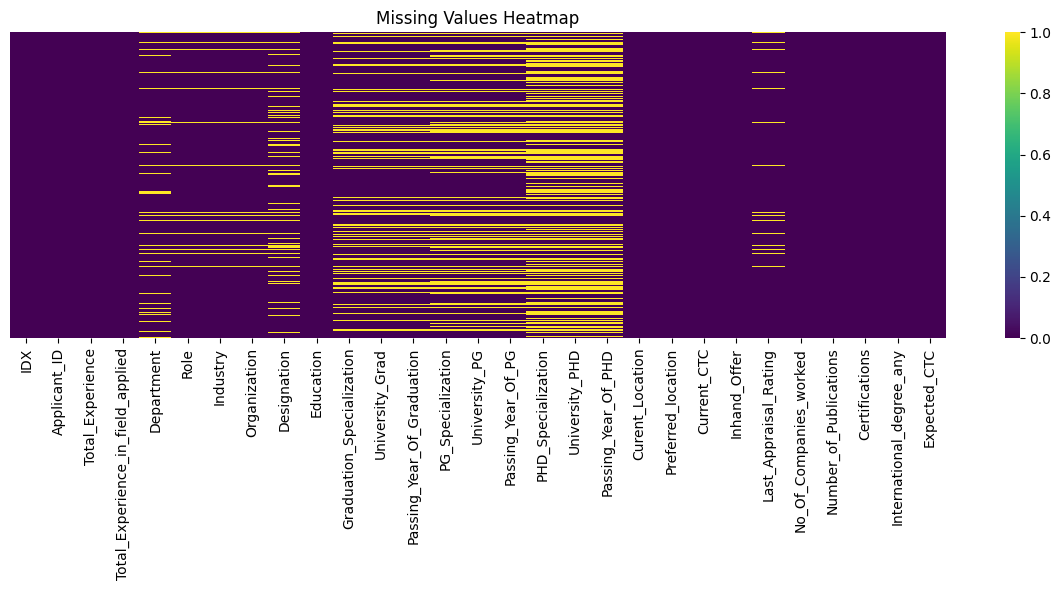

In [4]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Percentage', ascending=False)

print("=== MISSING VALUES ANALYSIS ===")
print(missing_df[missing_df['Missing_Count'] > 0])

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Target Variable Distribution

=== EXPECTED CTC STATISTICS ===
Mean: ₹2,250,155
Median: ₹2,252,136
Std Dev: ₹1,160,480
Min: ₹203,744
Max: ₹5,599,570


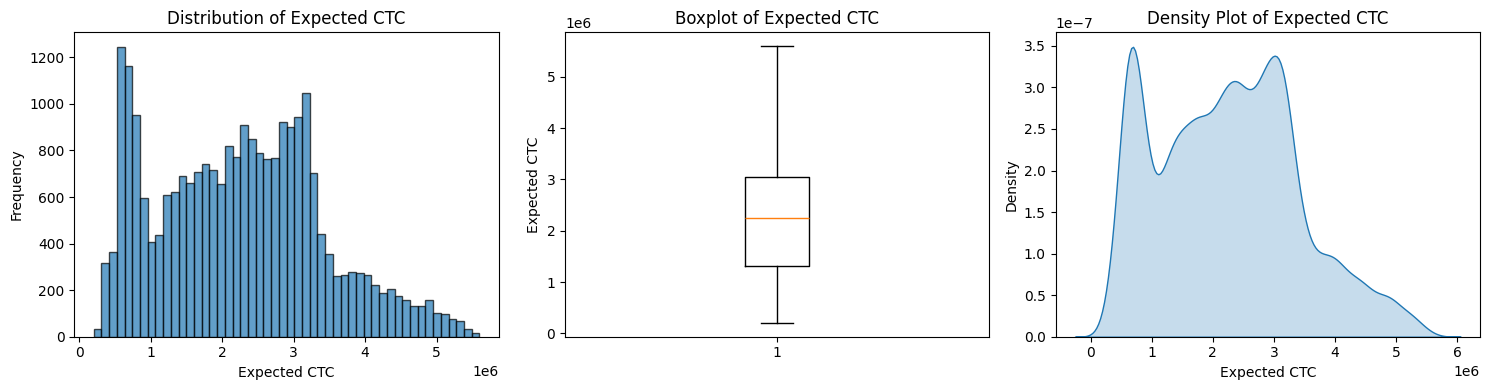


Skewness: 0.33


In [5]:
# Target variable analysis
print("=== EXPECTED CTC STATISTICS ===")
print(f"Mean: ₹{df['Expected_CTC'].mean():,.0f}")
print(f"Median: ₹{df['Expected_CTC'].median():,.0f}")
print(f"Std Dev: ₹{df['Expected_CTC'].std():,.0f}")
print(f"Min: ₹{df['Expected_CTC'].min():,.0f}")
print(f"Max: ₹{df['Expected_CTC'].max():,.0f}")

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Expected_CTC'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Expected CTC')
axes[0].set_xlabel('Expected CTC')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df['Expected_CTC'])
axes[1].set_title('Boxplot of Expected CTC')
axes[1].set_ylabel('Expected CTC')

# KDE plot
sns.kdeplot(df['Expected_CTC'], ax=axes[2], fill=True)
axes[2].set_title('Density Plot of Expected CTC')
axes[2].set_xlabel('Expected CTC')

plt.tight_layout()
plt.show()

# Check skewness
print(f"\nSkewness: {df['Expected_CTC'].skew():.2f}")

### Outlier Analysis

In [6]:
# Detect outliers in target variable
Q1 = df['Expected_CTC'].quantile(0.25)
Q3 = df['Expected_CTC'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Expected_CTC'] < lower_bound) | (df['Expected_CTC'] > upper_bound)]
print(f"Number of outliers in target: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

# Show outlier examples
if len(outliers) > 0:
    print("\nSample outliers:")
    print(outliers[['Applicant_ID', 'Total_Experience', 'Expected_CTC']].head())

Number of outliers in target: 0
Percentage of outliers: 0.00%


### Numerical Features Analysis

Numerical columns: ['IDX', 'Applicant_ID', 'Total_Experience', 'Total_Experience_in_field_applied', 'Passing_Year_Of_Graduation', 'Passing_Year_Of_PG', 'Passing_Year_Of_PHD', 'Current_CTC', 'No_Of_Companies_worked', 'Number_of_Publications', 'Certifications', 'International_degree_any', 'Expected_CTC']


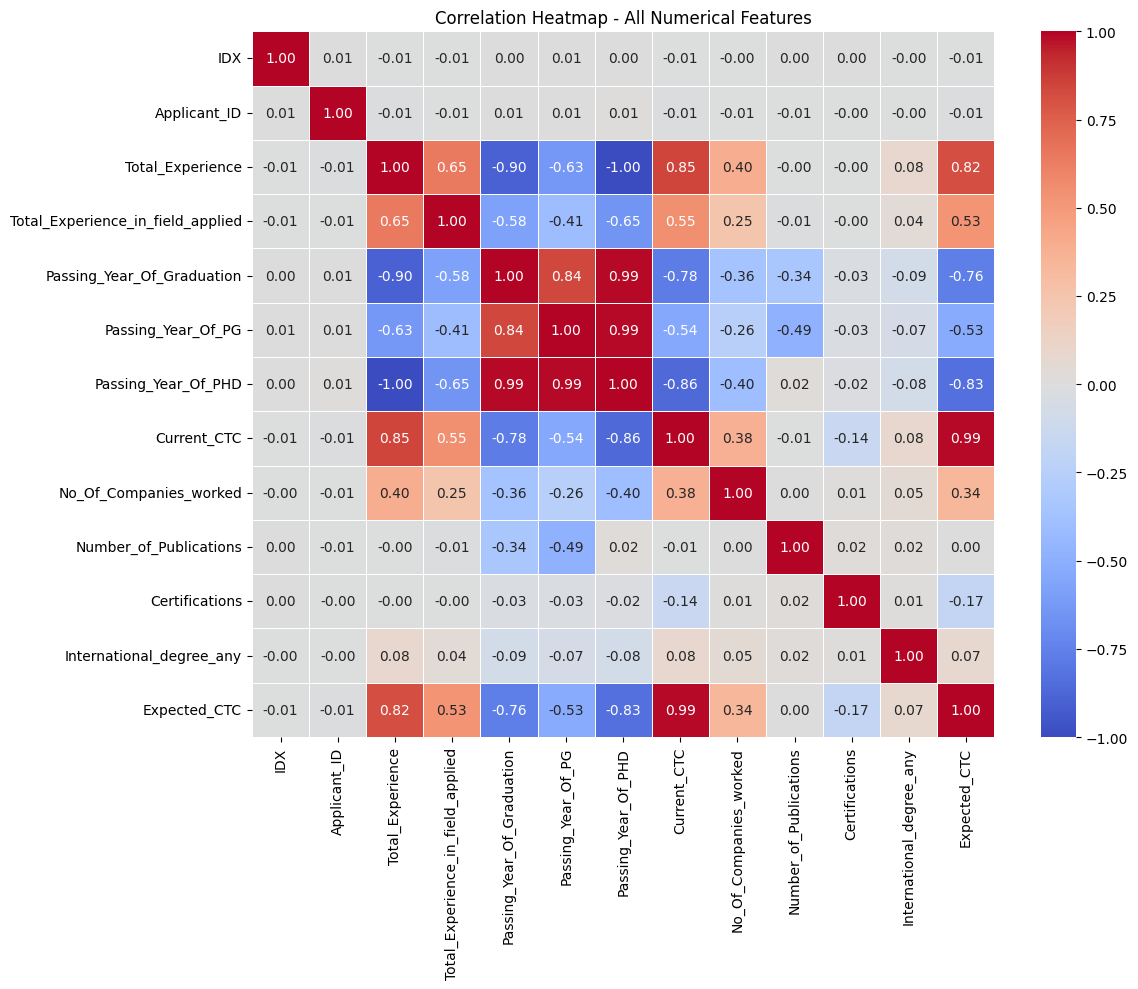


=== CORRELATION WITH EXPECTED_CTC ===
Expected_CTC                         1.000000
Current_CTC                          0.986718
Total_Experience                     0.816593
Total_Experience_in_field_applied    0.529115
No_Of_Companies_worked               0.343150
International_degree_any             0.074557
Number_of_Publications               0.001518
IDX                                 -0.006239
Applicant_ID                        -0.009300
Certifications                      -0.173992
Passing_Year_Of_PG                  -0.530964
Passing_Year_Of_Graduation          -0.758694
Passing_Year_Of_PHD                 -0.834222
Name: Expected_CTC, dtype: float64


In [7]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(numerical_cols)}")

# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - All Numerical Features')
plt.tight_layout()
plt.show()

# Correlation with target
corr_target = corr_matrix['Expected_CTC'].sort_values(ascending=False)
print("\n=== CORRELATION WITH EXPECTED_CTC ===")
print(corr_target)

### Categorical Features Analysis

Categorical columns: ['Department', 'Role', 'Industry', 'Organization', 'Designation', 'Education', 'Graduation_Specialization', 'University_Grad', 'PG_Specialization', 'University_PG', 'PHD_Specialization', 'University_PHD', 'Curent_Location', 'Preferred_location', 'Inhand_Offer', 'Last_Appraisal_Rating']


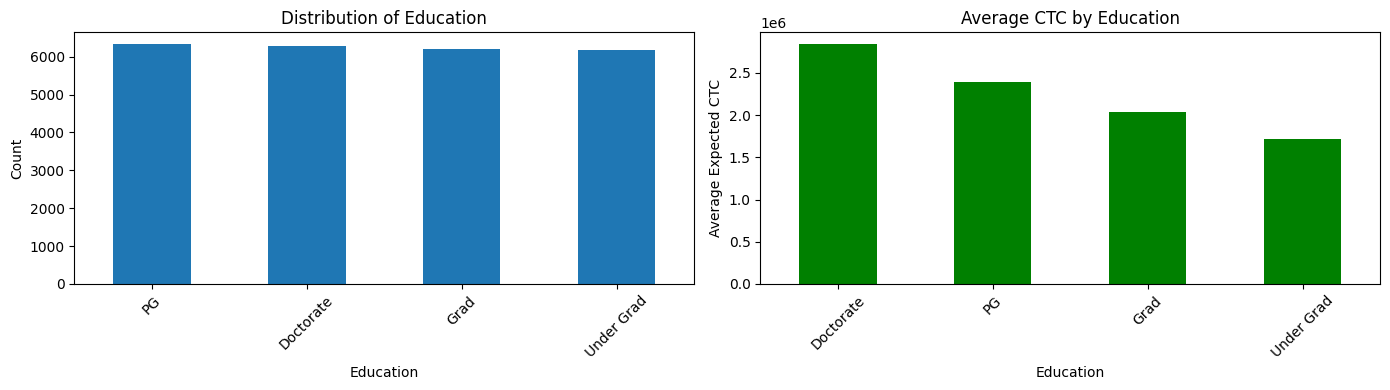


Top 5 Education by average salary:
Education
Doctorate     2.839321e+06
PG            2.398012e+06
Grad          2.033013e+06
Under Grad    1.717788e+06
Name: Expected_CTC, dtype: float64


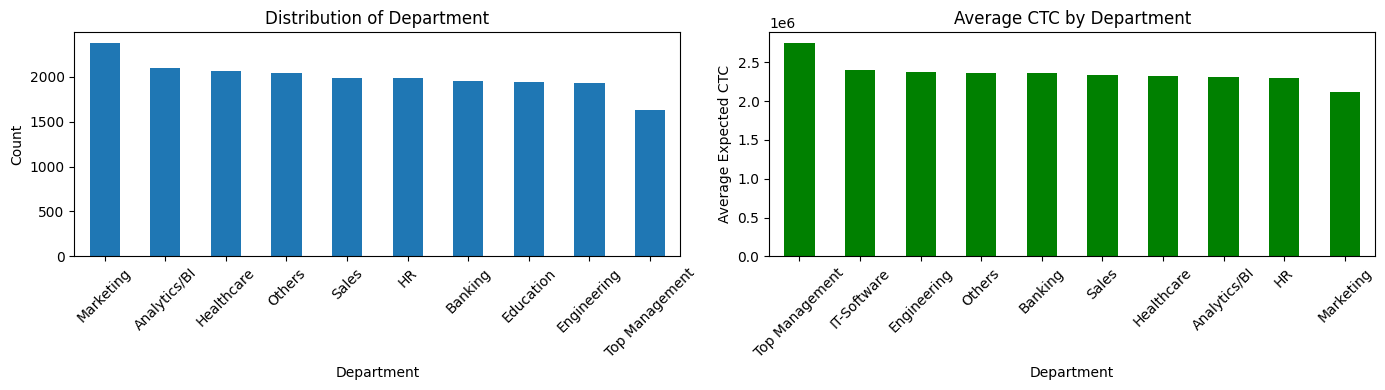


Top 5 Department by average salary:
Department
Top Management    2.748788e+06
IT-Software       2.397371e+06
Engineering       2.378852e+06
Others            2.357914e+06
Banking           2.356357e+06
Name: Expected_CTC, dtype: float64


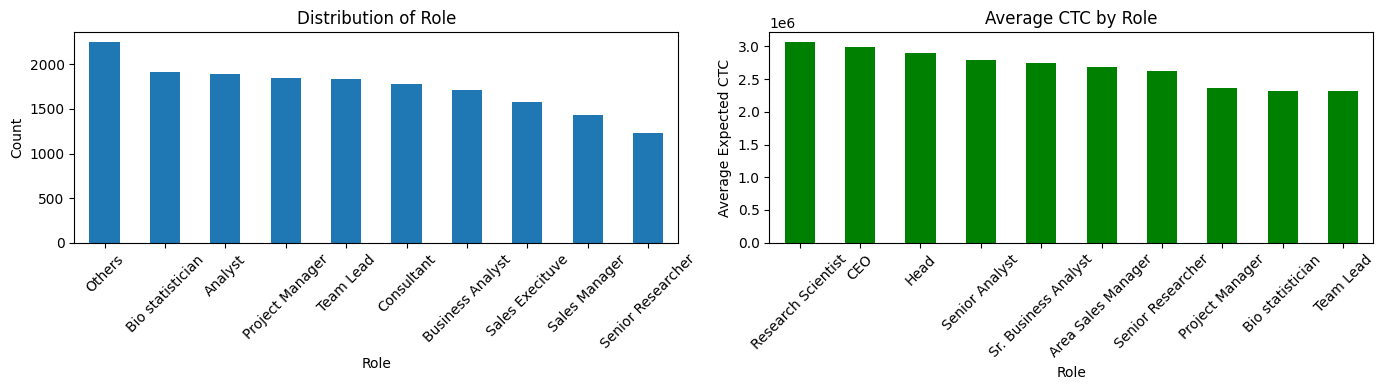


Top 5 Role by average salary:
Role
Research Scientist      3.062557e+06
CEO                     2.995342e+06
Head                    2.904600e+06
Senior Analyst          2.799188e+06
Sr. Business Analyst    2.740747e+06
Name: Expected_CTC, dtype: float64


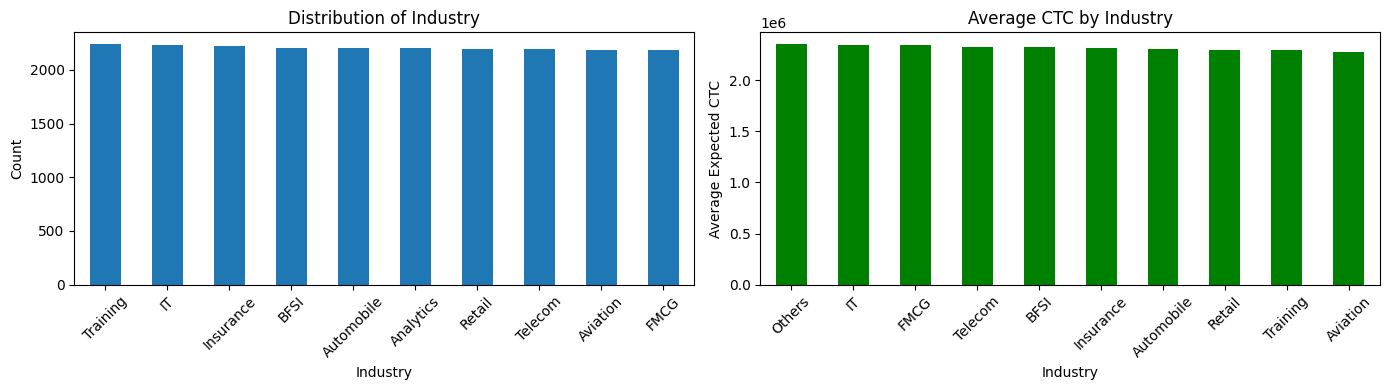


Top 5 Industry by average salary:
Industry
Others     2.350520e+06
IT         2.347257e+06
FMCG       2.347144e+06
Telecom    2.324385e+06
BFSI       2.321196e+06
Name: Expected_CTC, dtype: float64


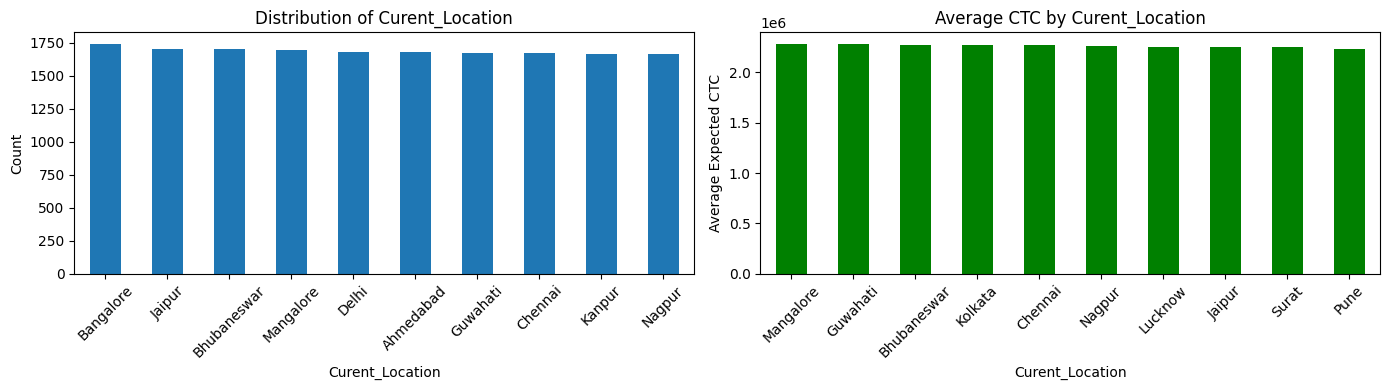


Top 5 Curent_Location by average salary:
Curent_Location
Mangalore      2.284521e+06
Guwahati       2.278209e+06
Bhubaneswar    2.277798e+06
Kolkata        2.277313e+06
Chennai        2.276808e+06
Name: Expected_CTC, dtype: float64


In [8]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

# Analyze important categorical features
important_cats = ['Education', 'Department', 'Role', 'Industry', 'Curent_Location']

for col in important_cats:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # Count plot
        df[col].value_counts().head(10).plot(kind='bar', ax=axes[0])
        axes[0].set_title(f'Distribution of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Average salary by category
        avg_salary = df.groupby(col)['Expected_CTC'].mean().sort_values(ascending=False).head(10)
        avg_salary.plot(kind='bar', ax=axes[1], color='green')
        axes[1].set_title(f'Average CTC by {col}')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Average Expected CTC')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop 5 {col} by average salary:")
        print(avg_salary.head())

### Experience Analysis

=== EXPERIENCE ANALYSIS ===
Total Experience range: 0 - 25 years
Field Experience range: 0 - 25 years


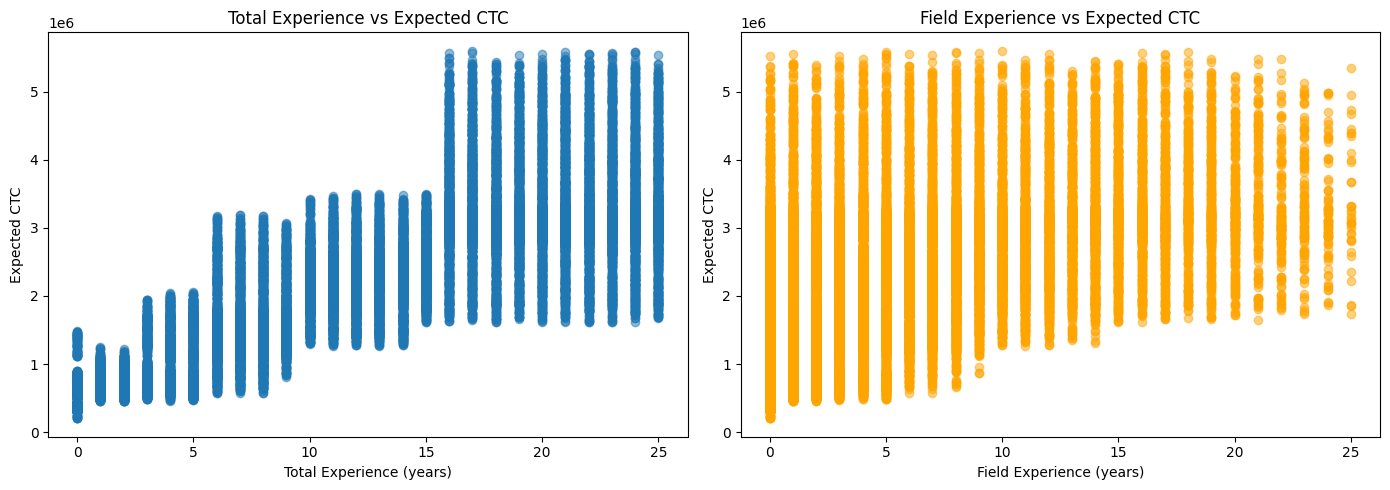


Correlation - Total Experience: 0.817
Correlation - Field Experience: 0.529


In [9]:
# Analyze experience features
print("=== EXPERIENCE ANALYSIS ===")
print(f"Total Experience range: {df['Total_Experience'].min()} - {df['Total_Experience'].max()} years")
print(f"Field Experience range: {df['Total_Experience_in_field_applied'].min()} - {df['Total_Experience_in_field_applied'].max()} years")

# Experience vs Salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Experience
axes[0].scatter(df['Total_Experience'], df['Expected_CTC'], alpha=0.5)
axes[0].set_xlabel('Total Experience (years)')
axes[0].set_ylabel('Expected CTC')
axes[0].set_title('Total Experience vs Expected CTC')

# Field Experience
axes[1].scatter(df['Total_Experience_in_field_applied'], df['Expected_CTC'], alpha=0.5, color='orange')
axes[1].set_xlabel('Field Experience (years)')
axes[1].set_ylabel('Expected CTC')
axes[1].set_title('Field Experience vs Expected CTC')

plt.tight_layout()
plt.show()

# Correlation with target
print(f"\nCorrelation - Total Experience: {df['Total_Experience'].corr(df['Expected_CTC']):.3f}")
print(f"Correlation - Field Experience: {df['Total_Experience_in_field_applied'].corr(df['Expected_CTC']):.3f}")

### Data Cleaning - Handle Missing Values

In [10]:
# Function to handle missing values
def handle_missing_values(df):
    df_clean = df.copy()
    
    # Drop columns with > 50% missing values
    threshold = 50
    missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
    cols_to_drop = missing_pct[missing_pct > threshold].index
    print(f"Dropping columns with >{threshold}% missing: {list(cols_to_drop)}")
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    # Fill categorical columns with 'Unknown'
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna('Unknown')
    
    # Fill numerical columns with median
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    return df_clean

# Apply cleaning
df_clean = handle_missing_values(df)
print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

Dropping columns with >50% missing: []

Cleaned dataset shape: (25000, 29)
Missing values after cleaning: 0


### Remove Zero CTC Rows

In [11]:
# Remove rows where Expected_CTC is 0 (freshers without salary data)
print(f"Rows with Expected_CTC = 0: {len(df_clean[df_clean['Expected_CTC'] == 0])}")

df_clean = df_clean[df_clean['Expected_CTC'] > 0]
print(f"Rows after removing zero CTC: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Rows with Expected_CTC = 0: 0
Rows after removing zero CTC: 25000
Rows removed: 0


### Feature Engineering - Part 1

In [12]:
# Create new features
df_fe = df_clean.copy()

# 1. Experience Ratio (field experience / total experience)
df_fe['Exp_Ratio'] = df_fe['Total_Experience_in_field_applied'] / (df_fe['Total_Experience'] + 1)

# 2. Education Level (numeric mapping)
edu_mapping = {
    'Under Grad': 0,
    'Grad': 1,
    'PG': 2,
    'Doctorate': 3
}
df_fe['Education_Level'] = df_fe['Education'].map(edu_mapping).fillna(1)

# 3. Total Education Years
df_fe['Total_Education_Years'] = 0
df_fe.loc[df_fe['Education'] == 'Under Grad', 'Total_Education_Years'] = 12
df_fe.loc[df_fe['Education'] == 'Grad', 'Total_Education_Years'] = 15
df_fe.loc[df_fe['Education'] == 'PG', 'Total_Education_Years'] = 17
df_fe.loc[df_fe['Education'] == 'Doctorate', 'Total_Education_Years'] = 22

# 4. Same Location flag
df_fe['Same_Location'] = (df_fe['Curent_Location'] == df_fe['Preferred_location']).astype(int)

# 5. Total Experience Bins (for analysis)
df_fe['Exp_Level'] = pd.cut(df_fe['Total_Experience'], 
                             bins=[0, 2, 5, 10, 15, 20, 100],
                             labels=['Fresher', 'Junior', 'Mid', 'Senior', 'Lead', 'Executive'])

print("Feature engineering completed!")
print(f"New features added: Exp_Ratio, Education_Level, Total_Education_Years, Same_Location, Exp_Level")
print(f"\nUpdated dataset shape: {df_fe.shape}")

Feature engineering completed!
New features added: Exp_Ratio, Education_Level, Total_Education_Years, Same_Location, Exp_Level

Updated dataset shape: (25000, 34)


### Feature Engineering - Part 2 (Handle Non-Numeric)

In [13]:
# Fill any remaining missing values in new features
df_fe['Exp_Ratio'] = df_fe['Exp_Ratio'].fillna(0)
df_fe['Total_Education_Years'] = df_fe['Total_Education_Years'].fillna(15)

# Verify no missing values remain
print("Missing values after feature engineering:")
print(df_fe.isnull().sum()[df_fe.isnull().sum() > 0])

# Display first few rows of new features
df_fe[['Total_Experience', 'Total_Experience_in_field_applied', 'Exp_Ratio', 
       'Education', 'Education_Level', 'Total_Education_Years', 'Same_Location']].head()

Missing values after feature engineering:
Exp_Level    908
dtype: int64


,Total_Experience,Total_Experience_in_field_applied,Exp_Ratio,Education,Education_Level,Total_Education_Years,Same_Location
0,0,0,0.000000,PG,2,17,0
1,23,14,0.583333,Doctorate,3,22,0
2,21,12,0.545455,Doctorate,3,22,0
3,15,8,0.500000,Doctorate,3,22,0
4,10,5,0.454545,Grad,1,15,1


### Encode Categorical Variables

In [14]:
# Identify columns for encoding
categorical_cols = df_fe.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {list(categorical_cols)}")

# Display unique value counts
for col in categorical_cols:
    print(f"{col}: {df_fe[col].nunique()} unique values")

# Frequency encoding for high cardinality columns
high_cardinality = ['Applicant_ID', 'University_Grad', 'University_PG', 'University_PHD',
                     'Graduation_Specialization', 'PG_Specialization', 'PHD_Specialization',
                     'Organization', 'Designation']

df_encoded = df_fe.copy()

# Drop high cardinality columns
for col in high_cardinality:
    if col in df_encoded.columns:
        df_encoded = df_encoded.drop(columns=[col])
        print(f"Dropped: {col}")

# Label encoding for medium cardinality columns
from sklearn.preprocessing import LabelEncoder

medium_cardinality = ['Department', 'Role', 'Industry', 'Education', 
                       'Curent_Location', 'Preferred_location', 'Last_Appraisal_Rating', 'Exp_Level']

le = LabelEncoder()
for col in medium_cardinality:
    if col in df_encoded.columns:
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))
        df_encoded = df_encoded.drop(columns=[col])
        print(f"Label encoded: {col}")

# Binary columns - one-hot encoding
binary_cols = ['International_degree_any', 'Same_Location']
for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True)
        print(f"One-hot encoded: {col}")

print(f"\nFinal encoded dataset shape: {df_encoded.shape}")

Categorical columns to encode: ['Department', 'Role', 'Industry', 'Organization', 'Designation', 'Education', 'Graduation_Specialization', 'University_Grad', 'PG_Specialization', 'University_PG', 'PHD_Specialization', 'University_PHD', 'Curent_Location', 'Preferred_location', 'Inhand_Offer', 'Last_Appraisal_Rating']
Department: 13 unique values
Role: 25 unique values
Industry: 12 unique values
Organization: 17 unique values
Designation: 19 unique values
Education: 4 unique values
Graduation_Specialization: 12 unique values
University_Grad: 14 unique values
PG_Specialization: 12 unique values
University_PG: 14 unique values
PHD_Specialization: 12 unique values
University_PHD: 14 unique values
Curent_Location: 15 unique values
Preferred_location: 15 unique values
Inhand_Offer: 2 unique values
Last_Appraisal_Rating: 6 unique values
Dropped: Applicant_ID
Dropped: University_Grad
Dropped: University_PG
Dropped: University_PHD
Dropped: Graduation_Specialization
Dropped: PG_Specialization
Dro

### Prepare Features and Target

In [15]:
# ==========================================
# PREPARE FEATURES AND TARGET (FIXED)
# ==========================================

# Separate features and target
X = df_encoded.drop('Expected_CTC', axis=1)
y = df_encoded['Expected_CTC']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# CHECK FOR NON-NUMERIC COLUMNS FIRST
print("\n=== CHECKING DATA TYPES ===")
print(X.dtypes.value_counts())

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nNon-numeric columns found: {non_numeric_cols}")

# Convert any remaining object columns to numeric
for col in non_numeric_cols:
    print(f"Converting {col} to numeric...")
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill any NaN values created from conversion
X = X.fillna(X.median())

# Verify all columns are now numeric
print(f"\nAfter conversion - All numeric: {X.select_dtypes(include=['object']).empty}")

# Now remove constant columns (columns with zero variance)
# Note: We need to select only numeric columns for std calculation
numeric_cols = X.select_dtypes(include=[np.number]).columns
X_numeric = X[numeric_cols]

constant_cols = [col for col in X_numeric.columns if X_numeric[col].std() == 0]
print(f"\nConstant columns to drop: {constant_cols}")

# Drop constant columns from original X
X = X.drop(columns=constant_cols)

# Handle infinity values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print(f"\nFinal features shape after cleaning: {X.shape}")
print(f"Final features data types: {X.dtypes.value_counts()}")

Features shape: (25000, 24)
Target shape: (25000,)

=== CHECKING DATA TYPES ===
int64      17
float64     4
bool        2
object      1
Name: count, dtype: int64

Non-numeric columns found: ['Inhand_Offer']
Converting Inhand_Offer to numeric...

After conversion - All numeric: True

Constant columns to drop: []

Final features shape after cleaning: (25000, 24)
Final features data types: int64      17
float64     5
bool        2
Name: count, dtype: int64


### Feature Selection using Random Forest

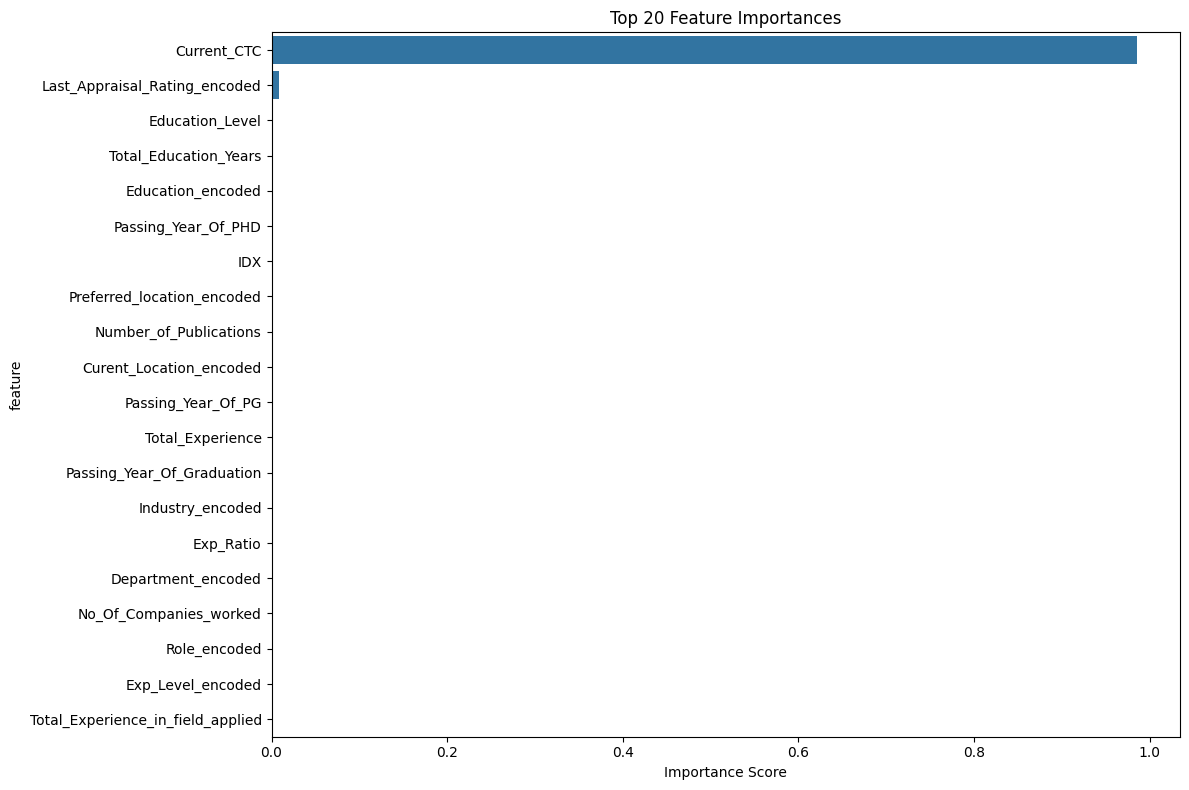


=== TOP 10 FEATURES ===
                          feature  importance
6                     Current_CTC    0.985278
20  Last_Appraisal_Rating_encoded    0.008356
12                Education_Level    0.001592
13          Total_Education_Years    0.001579
17              Education_encoded    0.001384
5             Passing_Year_Of_PHD    0.000563
0                             IDX    0.000271
19     Preferred_location_encoded    0.000161
9          Number_of_Publications    0.000143
18        Curent_Location_encoded    0.000142

Selected 20 features for modeling
Selected features: ['Current_CTC', 'Last_Appraisal_Rating_encoded', 'Education_Level', 'Total_Education_Years', 'Education_encoded', 'Passing_Year_Of_PHD', 'IDX', 'Preferred_location_encoded', 'Number_of_Publications', 'Curent_Location_encoded']...


In [16]:
# Quick Random Forest to identify important features
from sklearn.ensemble import RandomForestRegressor

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n=== TOP 10 FEATURES ===")
print(feature_importance.head(10))

# Select features with importance > 0.5%
top_features = feature_importance[feature_importance['importance'] > 0.005]['feature'].tolist()
if len(top_features) < 15:
    top_features = feature_importance.head(20)['feature'].tolist()

print(f"\nSelected {len(top_features)} features for modeling")
X_selected = X[top_features]
print(f"Selected features: {top_features[:10]}...")

### Train-Test Split

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target stats - Mean: ₹{y_train.mean():,.0f}, Std: ₹{y_train.std():,.0f}")
print(f"Test target stats - Mean: ₹{y_test.mean():,.0f}, Std: ₹{y_test.std():,.0f}")

Training set size: (20000, 20)
Test set size: (5000, 20)
Training target stats - Mean: ₹2,248,424, Std: ₹1,159,853
Test target stats - Mean: ₹2,257,075, Std: ₹1,163,076


### Feature Scaling

In [18]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print(f"Training data mean (after scaling): {X_train_scaled.mean():.2f}")
print(f"Training data std (after scaling): {X_train_scaled.std():.2f}")

Scaling completed!
Training data mean (after scaling): 0.00
Training data std (after scaling): 1.00


### Model Building - Multiple Algorithms

In [19]:
# Dictionary of models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Train and evaluate
results = []

print("=" * 80)
print("MODEL TRAINING AND EVALUATION")
print("=" * 80)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae
    })
    
    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  Train RMSE: ₹{train_rmse:,.0f} | Test RMSE: ₹{test_rmse:,.0f}")
    print(f"  Train MAE: ₹{train_mae:,.0f} | Test MAE: ₹{test_mae:,.0f}")

# Results dataframe
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.sort_values('Test_R2', ascending=False).to_string())

MODEL TRAINING AND EVALUATION

Linear Regression:
  Train R²: 0.9830 | Test R²: 0.9828
  Train RMSE: ₹151,093 | Test RMSE: ₹152,737
  Train MAE: ₹119,991 | Test MAE: ₹121,619

Ridge Regression:
  Train R²: 0.9830 | Test R²: 0.9828
  Train RMSE: ₹151,093 | Test RMSE: ₹152,738
  Train MAE: ₹119,983 | Test MAE: ₹121,614

Lasso Regression:
  Train R²: 0.9830 | Test R²: 0.9828
  Train RMSE: ₹151,093 | Test RMSE: ₹152,737
  Train MAE: ₹119,991 | Test MAE: ₹121,619

Random Forest:
  Train R²: 0.9998 | Test R²: 0.9986
  Train RMSE: ₹16,735 | Test RMSE: ₹42,763
  Train MAE: ₹9,398 | Test MAE: ₹24,966

Gradient Boosting:
  Train R²: 0.9984 | Test R²: 0.9984
  Train RMSE: ₹45,689 | Test RMSE: ₹46,282
  Train MAE: ₹29,504 | Test MAE: ₹30,058

XGBoost:
  Train R²: 0.9995 | Test R²: 0.9986
  Train RMSE: ₹26,328 | Test RMSE: ₹43,959
  Train MAE: ₹17,619 | Test MAE: ₹25,948

MODEL PERFORMANCE SUMMARY
               Model  Train_R2   Test_R2     Train_RMSE      Test_RMSE      Train_MAE       Test_MAE
3

### Model Comparison Visualization

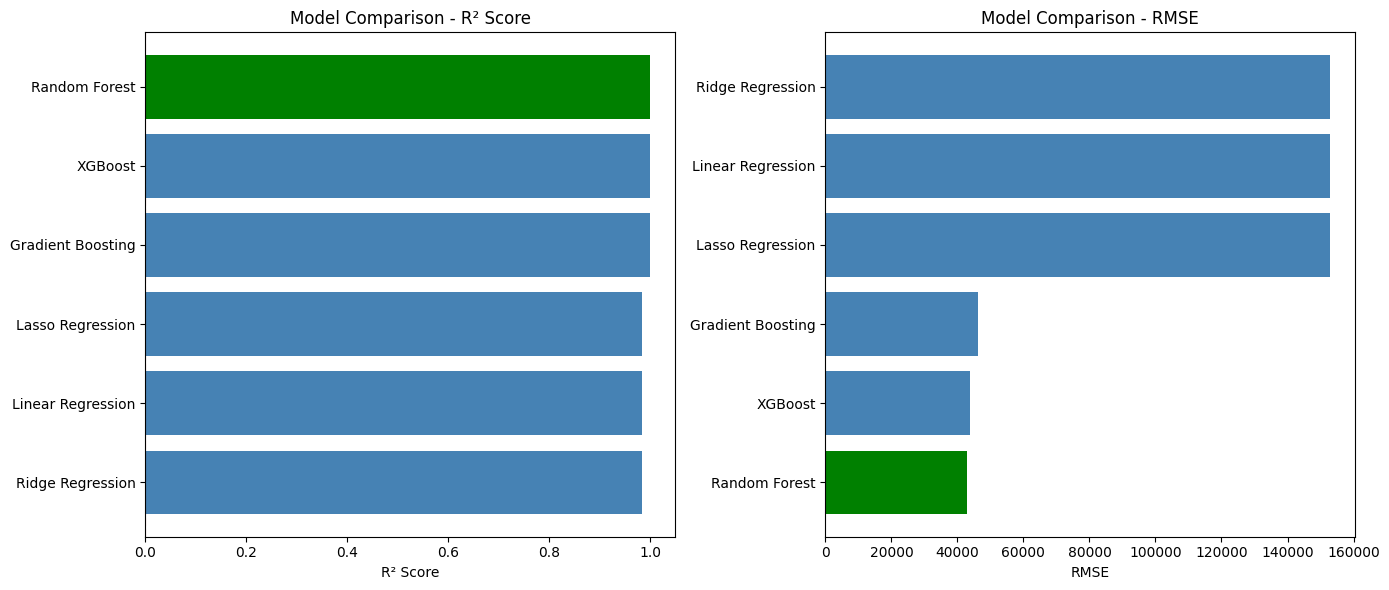

In [20]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² Score comparison
results_sorted = results_df.sort_values('Test_R2', ascending=True)
colors = ['green' if x == results_sorted['Test_R2'].max() else 'steelblue' for x in results_sorted['Test_R2']]
axes[0].barh(results_sorted['Model'], results_sorted['Test_R2'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison - R² Score')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# RMSE comparison
results_sorted_rmse = results_df.sort_values('Test_RMSE', ascending=True)
colors_rmse = ['green' if x == results_sorted_rmse['Test_RMSE'].min() else 'steelblue' for x in results_sorted_rmse['Test_RMSE']]
axes[1].barh(results_sorted_rmse['Model'], results_sorted_rmse['Test_RMSE'], color=colors_rmse)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison - RMSE')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning - XGBoost

In [21]:
print("=" * 60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("=" * 60)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Grid search
xgb = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV R² score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_xgb = grid_search.best_estimator_
y_train_pred_tuned = best_xgb.predict(X_train_scaled)
y_test_pred_tuned = best_xgb.predict(X_test_scaled)

train_r2_tuned = r2_score(y_train, y_train_pred_tuned)
test_r2_tuned = r2_score(y_test, y_test_pred_tuned)
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))

print(f"\nTuned XGBoost Performance:")
print(f"  Train R²: {train_r2_tuned:.4f}")
print(f"  Test R²: {test_r2_tuned:.4f}")
print(f"  Test RMSE: ₹{test_rmse_tuned:,.0f}")

HYPERPARAMETER TUNING - XGBOOST
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV R² score: 0.9987

Tuned XGBoost Performance:
  Train R²: 0.9990
  Test R²: 0.9988
  Test RMSE: ₹40,815


### Hyperparameter Tuning - Random Forest

In [22]:
# ==========================================
# FASTEST RANDOM FOREST (USE DEFAULTS)
# ==========================================

print("=" * 60)
print("RANDOM FOREST - DEFAULT PARAMETERS (Fastest)")
print("=" * 60)

# Use default Random Forest - already quite good!
best_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training default Random Forest...")
best_rf.fit(X_train_scaled, y_train)

y_test_pred_rf = best_rf.predict(X_test_scaled)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print(f"\n📊 Random Forest Performance (Default):")
print(f"   Test R²: {test_r2_rf:.4f}")
print(f"   Test RMSE: ₹{test_rmse_rf:,.0f}")
print(f"   Test MAE: ₹{mean_absolute_error(y_test, y_test_pred_rf):,.0f}")

# Skip tuned version - use default
best_rf_tuned = best_rf

RANDOM FOREST - DEFAULT PARAMETERS (Fastest)
Training default Random Forest...

📊 Random Forest Performance (Default):
   Test R²: 0.9986
   Test RMSE: ₹42,763
   Test MAE: ₹24,966


### Select Final Model

In [23]:
# Select best model
if test_r2_tuned > test_r2_rf:
    final_model = best_xgb
    model_name = "XGBoost"
    final_test_r2 = test_r2_tuned
    final_test_rmse = test_rmse_tuned
else:
    final_model = best_rf
    model_name = "Random Forest"
    final_test_r2 = test_r2_rf
    final_test_rmse = test_rmse_rf

print(f"Selected Model: {model_name}")
print(f"Final Test R²: {final_test_r2:.4f}")
print(f"Final Test RMSE: ₹{final_test_rmse:,.0f}")

# Final predictions
y_pred_final = final_model.predict(X_test_scaled)
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"Final Test MAE: ₹{final_mae:,.0f}")

Selected Model: XGBoost
Final Test R²: 0.9988
Final Test RMSE: ₹40,815
Final Test MAE: ₹23,721


### Final Model Evaluation Plots

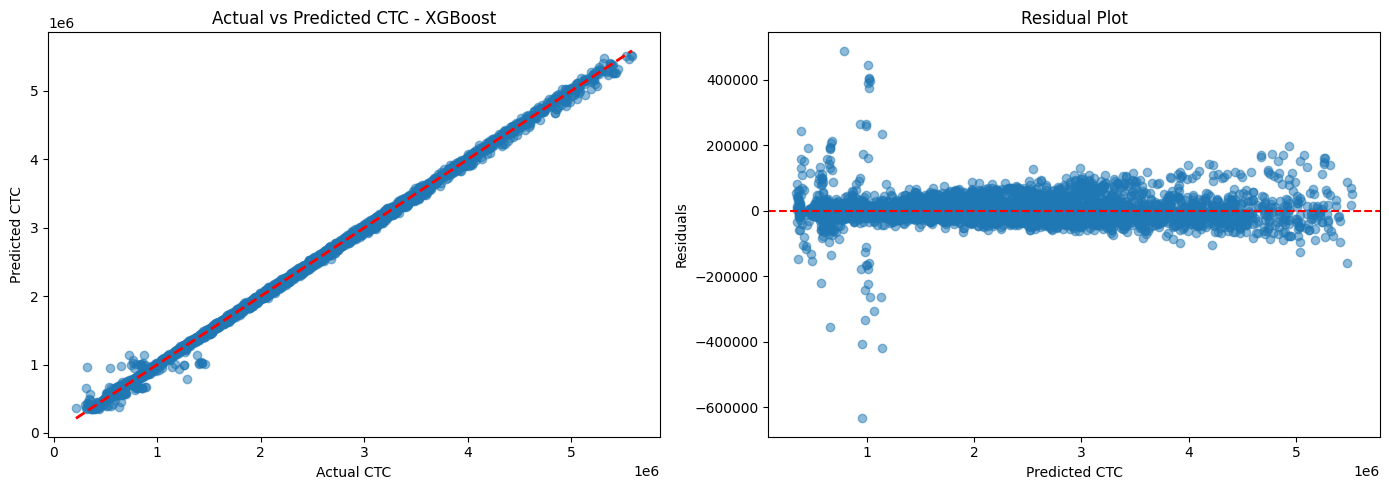

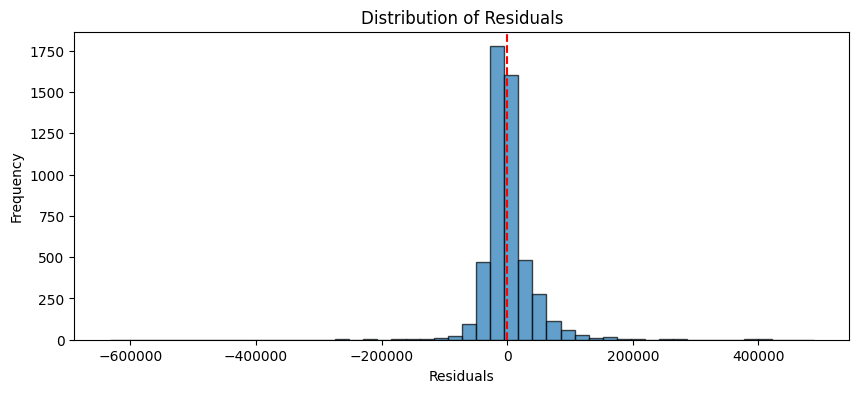

Residual Statistics:
  Mean: ₹1,028
  Std: ₹40,806
  Min: ₹-633,205
  Max: ₹488,806


In [24]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_final, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual CTC')
axes[0].set_ylabel('Predicted CTC')
axes[0].set_title(f'Actual vs Predicted CTC - {model_name}')

# Residual plot
residuals = y_test - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted CTC')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

print(f"Residual Statistics:")
print(f"  Mean: ₹{residuals.mean():,.0f}")
print(f"  Std: ₹{residuals.std():,.0f}")
print(f"  Min: ₹{residuals.min():,.0f}")
print(f"  Max: ₹{residuals.max():,.0f}")

### Feature Importance - Final Model

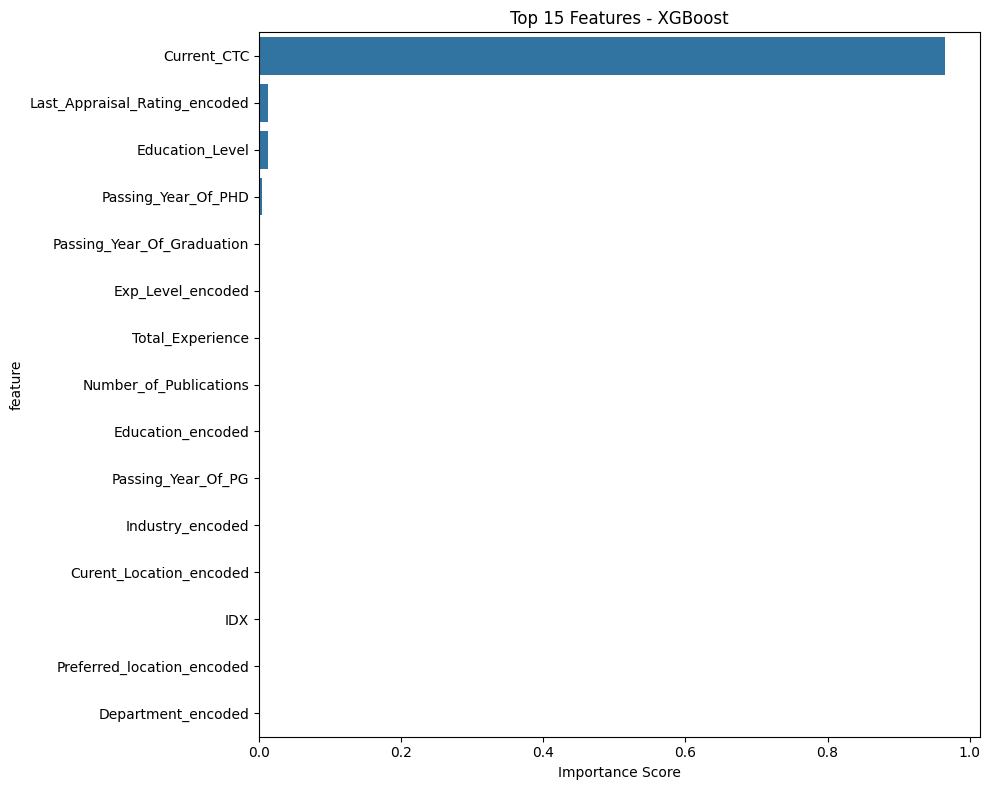

=== TOP 10 MOST IMPORTANT FEATURES ===
1. Current_CTC: 0.9657
2. Last_Appraisal_Rating_encoded: 0.0124
3. Education_Level: 0.0121
6. Passing_Year_Of_PHD: 0.0042
13. Passing_Year_Of_Graduation: 0.0015
19. Exp_Level_encoded: 0.0008
12. Total_Experience: 0.0007
9. Number_of_Publications: 0.0006
5. Education_encoded: 0.0004
11. Passing_Year_Of_PG: 0.0002


In [25]:
# Get feature importance from final model
if model_name == "XGBoost":
    importance = final_model.feature_importances_
else:
    importance = final_model.feature_importances_

feature_importance_final = pd.DataFrame({
    'feature': X_selected.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_final.head(15), x='importance', y='feature')
plt.title(f'Top 15 Features - {model_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== TOP 10 MOST IMPORTANT FEATURES ===")
for i, row in feature_importance_final.head(10).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

### Business Insights

In [26]:
print("=" * 60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("\n📊 KEY FINDINGS:")
print("-" * 40)

print("\n1. TOP SALARY DRIVERS:")
for i, row in feature_importance_final.head(5).iterrows():
    print(f"   • {row['feature']}")

print("\n2. MODEL PERFORMANCE:")
print(f"   • R² Score: {final_test_r2:.2%} (explained variance)")
print(f"   • Average Error: ₹{final_mae:,.0f}")
print(f"   • Model Type: {model_name}")

print("\n3. SALARY TRENDS BY CATEGORY:")
# Analyze original data for insights
edu_salaries = df_clean.groupby('Education')['Expected_CTC'].mean().sort_values(ascending=False)
print(f"   • Highest paying education: {edu_salaries.index[0]} (₹{edu_salaries.iloc[0]:,.0f})")

if 'Department' in df_clean.columns:
    dept_salaries = df_clean.groupby('Department')['Expected_CTC'].mean().sort_values(ascending=False)
    print(f"   • Highest paying department: {dept_salaries.index[0]} (₹{dept_salaries.iloc[0]:,.0f})")

print("\n💡 RECOMMENDATIONS:")
print("-" * 40)
print("1. Deploy this model to automate salary offers for candidates")
print("2. Use the model to audit existing salaries for fairness")
print("3. Regularly retrain the model with new hiring data")
print("4. Consider adding location cost indices for better accuracy")
print("5. Monitor for any bias in predictions across demographics")

print("\n⚠️ LIMITATIONS:")
print("-" * 40)
print("1. Model accuracy depends on historical data quality")
print("2. Missing data for some candidates may affect predictions")
print("3. Market conditions change - model needs periodic updates")

BUSINESS INSIGHTS & RECOMMENDATIONS

📊 KEY FINDINGS:
----------------------------------------

1. TOP SALARY DRIVERS:
   • Current_CTC
   • Last_Appraisal_Rating_encoded
   • Education_Level
   • Passing_Year_Of_PHD
   • Passing_Year_Of_Graduation

2. MODEL PERFORMANCE:
   • R² Score: 99.88% (explained variance)
   • Average Error: ₹23,721
   • Model Type: XGBoost

3. SALARY TRENDS BY CATEGORY:
   • Highest paying education: Doctorate (₹2,839,321)
   • Highest paying department: Top Management (₹2,748,788)

💡 RECOMMENDATIONS:
----------------------------------------
1. Deploy this model to automate salary offers for candidates
2. Use the model to audit existing salaries for fairness
3. Regularly retrain the model with new hiring data
4. Consider adding location cost indices for better accuracy
5. Monitor for any bias in predictions across demographics

⚠️ LIMITATIONS:
----------------------------------------
1. Model accuracy depends on historical data quality
2. Missing data for some 

### Prediction Function

In [27]:
def predict_salary(candidate_data, model, scaler, feature_columns):
    """
    Predict salary for a new candidate
    
    Parameters:
    candidate_data: dict with candidate information
    model: trained model
    scaler: fitted StandardScaler
    feature_columns: list of feature names
    
    Returns:
    predicted_salary: float
    """
    # Create dataframe from candidate data
    candidate_df = pd.DataFrame([candidate_data])
    
    # Ensure all required columns exist
    for col in feature_columns:
        if col not in candidate_df.columns:
            candidate_df[col] = 0
    
    # Select only required features
    candidate_df = candidate_df[feature_columns]
    
    # Handle any missing values
    candidate_df = candidate_df.fillna(0)
    
    # Scale and predict
    candidate_scaled = scaler.transform(candidate_df)
    prediction = model.predict(candidate_scaled)[0]
    
    return prediction

# Example usage
sample_candidate = {
    'Total_Experience': 8,
    'Total_Experience_in_field_applied': 5,
    'Education_Level': 2,
    'Exp_Ratio': 0.625,
    'Total_Education_Years': 17,
    # Add other features as needed
}

# Fill missing features with 0
for col in X_selected.columns:
    if col not in sample_candidate:
        sample_candidate[col] = 0

# Example prediction
predicted = predict_salary(sample_candidate, final_model, scaler, X_selected.columns)
print(f"Predicted salary for sample candidate: ₹{predicted:,.0f}")

Predicted salary for sample candidate: ₹540,115


### Save Model for Deployment

In [28]:
import joblib
from datetime import datetime

# Save model and artifacts
joblib.dump(final_model, 'salary_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_selected.columns.tolist(), 'feature_columns.pkl')

# Save model metadata
model_metadata = {
    'model_type': model_name,
    'train_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'test_r2_score': final_test_r2,
    'test_rmse': final_test_rmse,
    'test_mae': final_mae,
    'features_used': X_selected.columns.tolist()
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)

print("=" * 50)
print("MODEL SAVED SUCCESSFULLY!")
print("=" * 50)
print("\nFiles saved:")
print("  ✓ salary_prediction_model.pkl")
print("  ✓ scaler.pkl")
print("  ✓ feature_columns.pkl")
print("  ✓ model_metadata.json")

print("\nModel Details:")
print(f"  Type: {model_name}")
print(f"  R² Score: {final_test_r2:.4f}")
print(f"  RMSE: ₹{final_test_rmse:,.0f}")
print(f"  MAE: ₹{final_mae:,.0f}")

MODEL SAVED SUCCESSFULLY!

Files saved:
  ✓ salary_prediction_model.pkl
  ✓ scaler.pkl
  ✓ feature_columns.pkl
  ✓ model_metadata.json

Model Details:
  Type: XGBoost
  R² Score: 0.9988
  RMSE: ₹40,815
  MAE: ₹23,721


### Load and Test Saved Model

In [29]:
# Load saved artifacts
loaded_model = joblib.load('salary_prediction_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_columns.pkl')

with open('model_metadata.json', 'r') as f:
    loaded_metadata = json.load(f)

print("Model loaded successfully!")
print(f"Model type: {loaded_metadata['model_type']}")
print(f"Expected R²: {loaded_metadata['test_r2_score']:.4f}")

# Quick validation
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
sample_scaled = loaded_scaler.transform(sample)
sample_pred = loaded_model.predict(sample_scaled)[0]
sample_actual = y_test.iloc[sample_idx]

print(f"\nSample validation:")
print(f"  Predicted: ₹{sample_pred:,.0f}")
print(f"  Actual: ₹{sample_actual:,.0f}")
print(f"  Error: ₹{abs(sample_pred - sample_actual):,.0f} ({abs(sample_pred - sample_actual)/sample_actual*100:.1f}%)")

Model loaded successfully!
Model type: XGBoost
Expected R²: 0.9988

Sample validation:
  Predicted: ₹3,106,073
  Actual: ₹3,113,073
  Error: ₹7,000 (0.2%)
